In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
print("Libraries ready!")

Libraries ready!


In [8]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("File loaded!")
print("Total rows:", len(df))
print(df.head(3))

Saving NLC_Filtered_Data 1(M001_Monthly) (1).csv to NLC_Filtered_Data 1(M001_Monthly) (1) (1).csv
File loaded!
Total rows: 40
  Plant Month_Year  Total_Qty_KG  Total_Amount_INR  Records
0  M001    2021-11         58630        2793625.72        4
1  M001    2022-02         38860        2629314.23        2
2  M001    2022-03         93990        6462395.33       10


In [9]:
m001 = df[df['Plant']=='M001'].copy()
m001 = m001.reset_index(drop=True)
m002 = df[df['Plant']=='M002'].copy()
m002 = m002.reset_index(drop=True)
m001.columns = ['Plant','Month_Year',
                'Total_Qty','Total_Amount',
                'Records']
m002.columns = ['Plant','Month_Year',
                'Total_Qty','Total_Amount',
                'Records']
print("Plants separated!")
print("M001 months:", len(m001))
print("M002 months:", len(m002))
print("\nM001 Data:")
print(m001[['Month_Year','Total_Qty',
            'Total_Amount']].to_string())
print("\nM002 Data:")
print(m002[['Month_Year','Total_Qty',
            'Total_Amount']].to_string())

Plants separated!
M001 months: 19
M002 months: 21

M001 Data:
   Month_Year  Total_Qty  Total_Amount
0     2021-11      58630    2793625.72
1     2022-02      38860    2629314.23
2     2022-03      93990    6462395.33
3     2022-04       8580     601288.14
4     2022-05      99360    7743196.63
5     2022-06      73300    5930781.49
6     2022-07      47370    3807274.62
7     2022-08       9170     725304.82
8     2022-09      37650    2977941.83
9     2022-10      60630    4907166.79
10    2022-11      41880    3493059.86
11    2023-01      48120    3493427.07
12    2023-03      57870    3970182.96
13    2023-05      38600    2367585.05
14    2023-06      58940    3615167.44
15    2023-09     157480    7577686.95
16    2023-10      53270    2364740.53
17    2023-11      57260    2795914.20
18    2023-12      20970    1023931.57

M002 Data:
   Month_Year  Total_Qty  Total_Amount
0     2021-11      26260    1251246.99
1     2022-03      29710    2004543.70
2     2022-04      25100    1

In [10]:
print("="*50)
print("M001 STATISTICS - MINE I")
print("="*50)
print("Total Months    :", len(m001))
print("Total Qty (KG)  :", m001['Total_Qty'].sum())
print("Total Amount    : ₹",
      round(m001['Total_Amount'].sum(),2))
print("Avg Monthly Qty :",
      round(m001['Total_Qty'].mean(),2), "KG")
print("Max Monthly Qty :",
      round(m001['Total_Qty'].max(),2), "KG")
print("Min Monthly Qty :",
      round(m001['Total_Qty'].min(),2), "KG")
print("\n" + "="*50)
print("M002 STATISTICS - MINE II")
print("="*50)
print("Total Months    :", len(m002))
print("Total Qty (KG)  :", m002['Total_Qty'].sum())
print("Total Amount    : ₹",
      round(m002['Total_Amount'].sum(),2))
print("Avg Monthly Qty :",
      round(m002['Total_Qty'].mean(),2), "KG")
print("Max Monthly Qty :",
      round(m002['Total_Qty'].max(),2), "KG")
print("Min Monthly Qty :",
      round(m002['Total_Qty'].min(),2), "KG")

M001 STATISTICS - MINE I
Total Months    : 19
Total Qty (KG)  : 1061930
Total Amount    : ₹ 69279985.23
Avg Monthly Qty : 55891.05 KG
Max Monthly Qty : 157480 KG
Min Monthly Qty : 8580 KG

M002 STATISTICS - MINE II
Total Months    : 21
Total Qty (KG)  : 730570
Total Amount    : ₹ 47439045.41
Avg Monthly Qty : 34789.05 KG
Max Monthly Qty : 170820 KG
Min Monthly Qty : 2310 KG


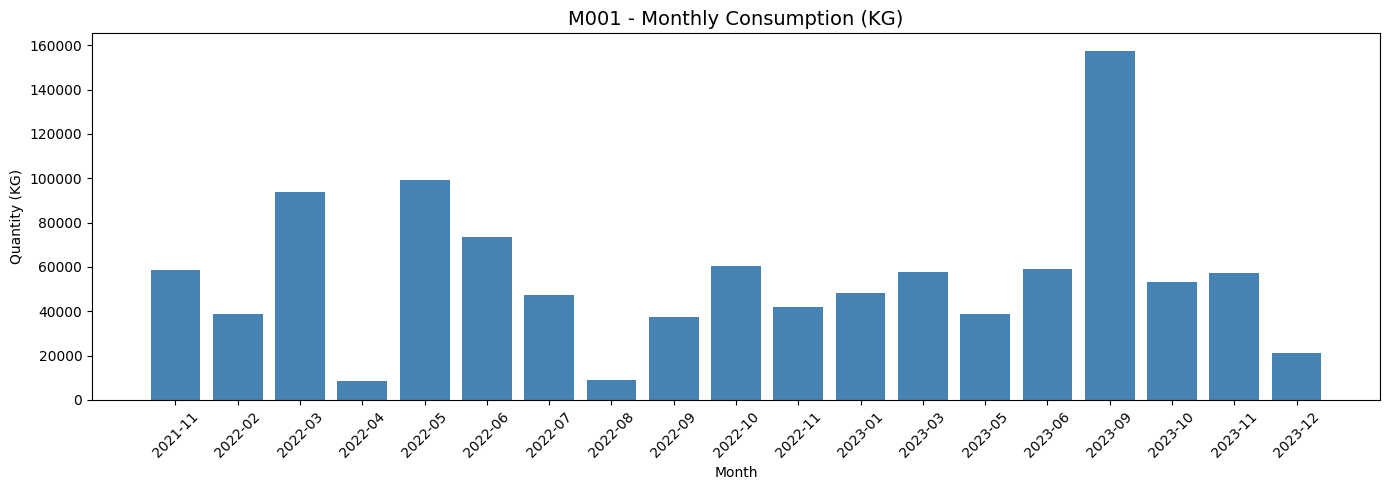

M001 graph saved!


In [11]:
plt.figure(figsize=(14,5))
plt.bar(m001['Month_Year'],
        m001['Total_Qty'],
        color='steelblue')
plt.title('M001 - Monthly Consumption (KG)',
          fontsize=14)
plt.xlabel('Month')
plt.ylabel('Quantity (KG)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('m001_consumption.png', dpi=150)
plt.show()
print("M001 graph saved!")

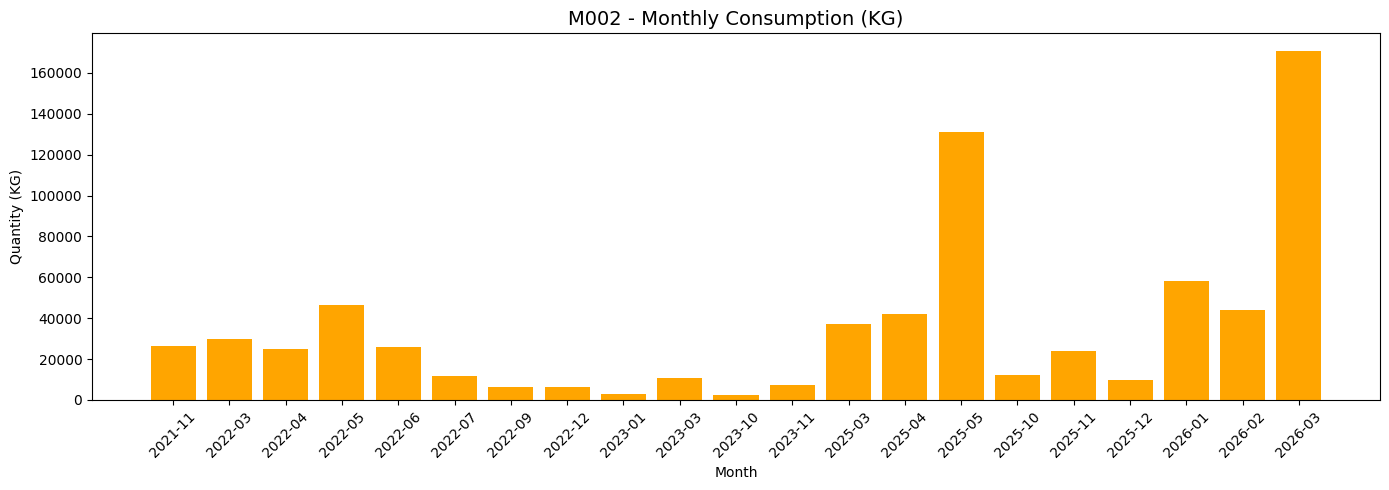

M002 graph saved!


In [12]:
plt.figure(figsize=(14,5))
plt.bar(m002['Month_Year'],
        m002['Total_Qty'],
        color='orange')
plt.title('M002 - Monthly Consumption (KG)',
          fontsize=14)
plt.xlabel('Month')
plt.ylabel('Quantity (KG)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('m002_consumption.png', dpi=150)
plt.show()
print("M002 graph saved!")

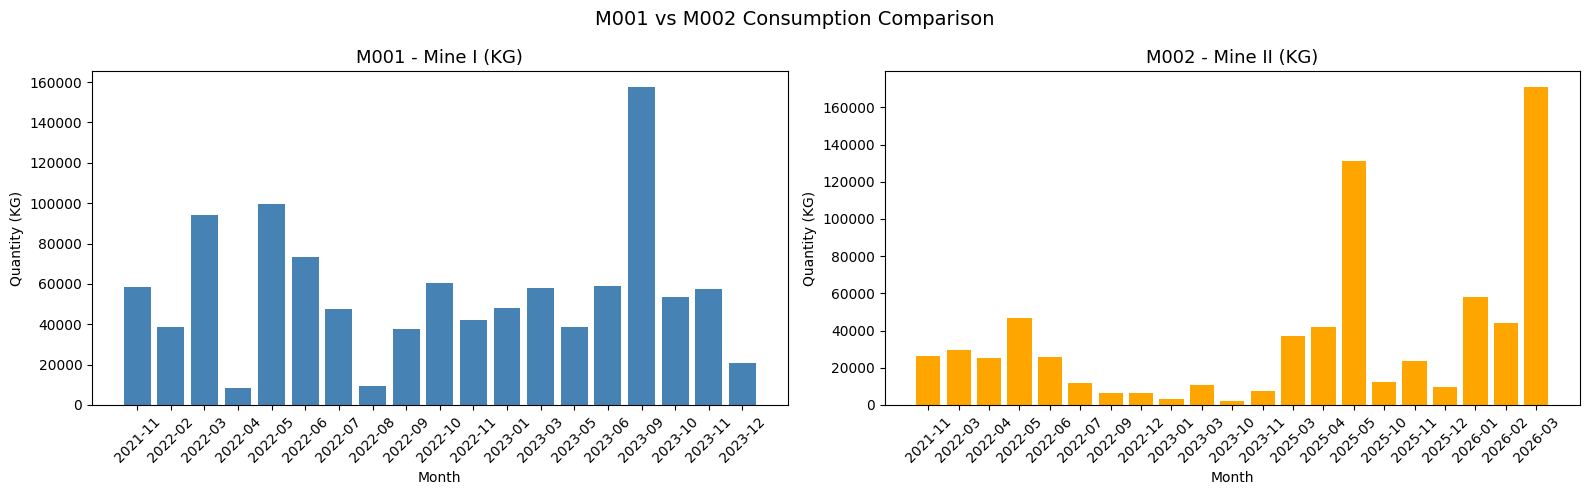

Comparison graph saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

axes[0].bar(m001['Month_Year'],
            m001['Total_Qty'],
            color='steelblue')
axes[0].set_title('M001 - Mine I (KG)',
                  fontsize=13)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Quantity (KG)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(m002['Month_Year'],
            m002['Total_Qty'],
            color='orange')
axes[1].set_title('M002 - Mine II (KG)',
                  fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Quantity (KG)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('M001 vs M002 Consumption Comparison',
             fontsize=14)
plt.tight_layout()
plt.savefig('comparison_graph.png', dpi=150)
plt.show()
print("Comparison graph saved!")

In [15]:
model_m001 = ARIMA(m001['Total_Qty'],
                   order=(1,1,1))
result_m001 = model_m001.fit()
forecast_m001 = result_m001.forecast(steps=6)
print("M001 ARIMA Forecast!")
print("\nNext 6 Months (KG):")
for i, val in enumerate(forecast_m001, 1):
    print(f"Month {i}: {round(val,2)} KG")

M001 ARIMA Forecast!

Next 6 Months (KG):
Month 1: 56840.37 KG
Month 2: 53984.67 KG
Month 3: 54212.01 KG
Month 4: 54193.92 KG
Month 5: 54195.36 KG
Month 6: 54195.24 KG


In [16]:
try:
    model_m002 = ARIMA(m002['Total_Qty'],
                       order=(1,1,1))
    result_m002 = model_m002.fit()
    forecast_m002 = result_m002.forecast(steps=6)
    print("M002 ARIMA (1,1,1) Forecast!")
except:
    model_m002 = ARIMA(m002['Total_Qty'],
                       order=(1,0,0))
    result_m002 = model_m002.fit()
    forecast_m002 = result_m002.forecast(steps=6)
    print(" M002 ARIMA (1,0,0) Forecast!")
print("\nNext 6 Months (KG):")
for i, val in enumerate(forecast_m002, 1):
    print(f"Month {i}: {round(val,2)} KG")

M002 ARIMA (1,1,1) Forecast!

Next 6 Months (KG):
Month 1: 116481.18 KG
Month 2: 167825.54 KG
Month 3: 119310.62 KG
Month 4: 165152.03 KG
Month 5: 121836.8 KG
Month 6: 162765.05 KG


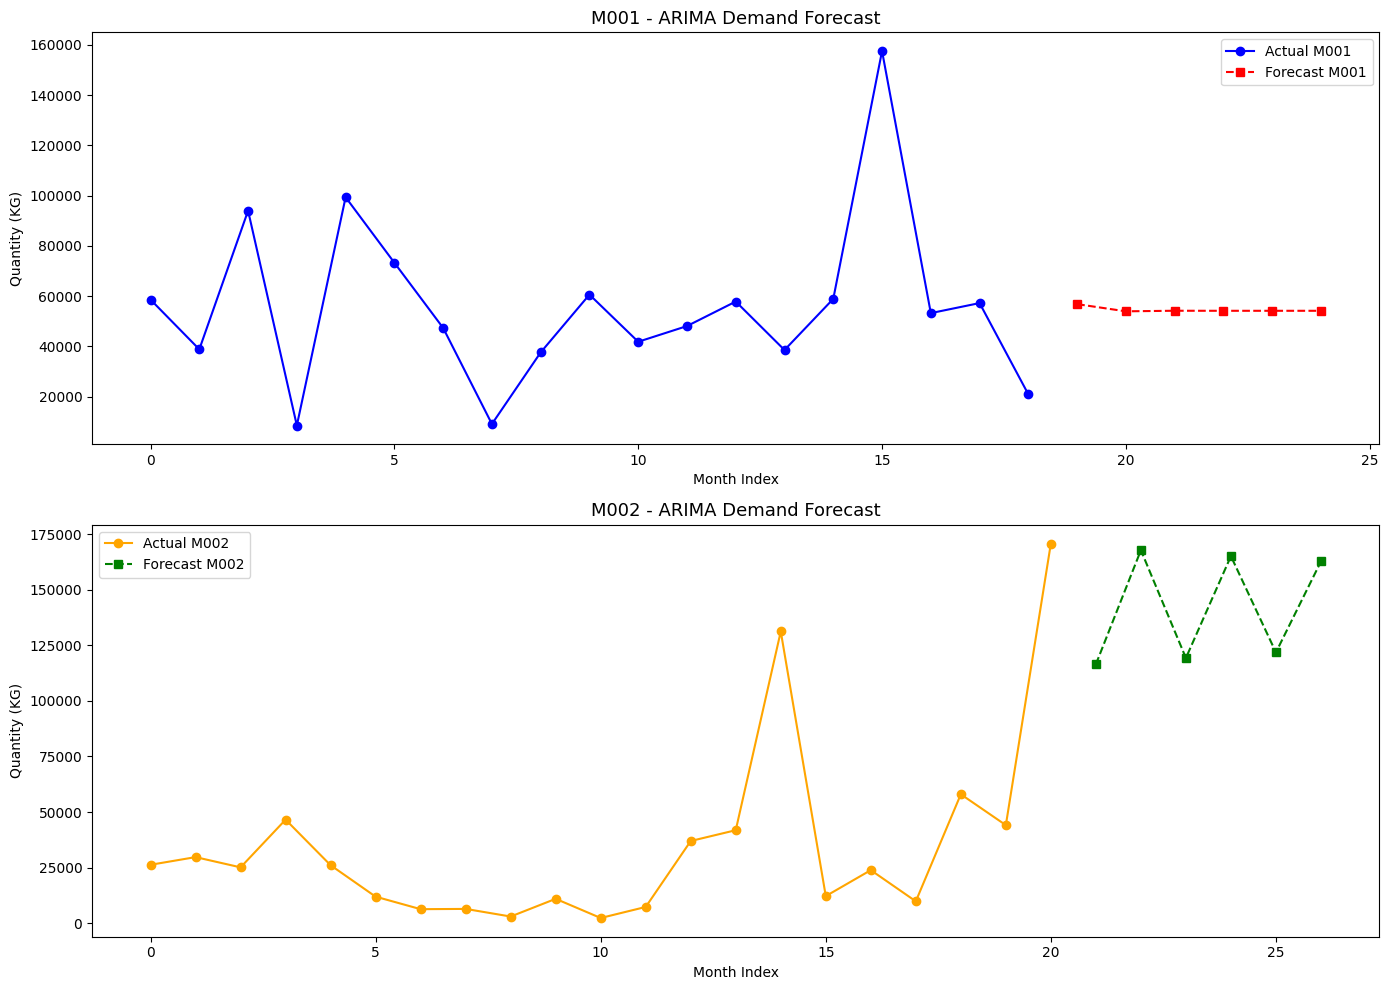

Forecast graph saved!


In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14,10))
axes[0].plot(range(len(m001)),
             m001['Total_Qty'],
             marker='o', color='blue',
             label='Actual M001')
axes[0].plot(range(len(m001),
                   len(m001)+6),
             forecast_m001,
             marker='s', color='red',
             linestyle='--',
             label='Forecast M001')
axes[0].set_title('M001 - ARIMA Demand Forecast',
                  fontsize=13)
axes[0].set_xlabel('Month Index')
axes[0].set_ylabel('Quantity (KG)')
axes[0].legend()
axes[1].plot(range(len(m002)),
             m002['Total_Qty'],
             marker='o', color='orange',
             label='Actual M002')
axes[1].plot(range(len(m002),
                   len(m002)+6),
             forecast_m002,
             marker='s', color='green',
             linestyle='--',
             label='Forecast M002')
axes[1].set_title('M002 - ARIMA Demand Forecast',
                  fontsize=13)
axes[1].set_xlabel('Month Index')
axes[1].set_ylabel('Quantity (KG)')
axes[1].legend()
plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=150)
plt.show()
print("Forecast graph saved!")

In [18]:
m001_price = m001['Total_Amount'].sum() / \
             m001['Total_Qty'].sum()
m002_price = m002['Total_Amount'].sum() / \
             m002['Total_Qty'].sum()
print("M001 Avg Price/KG: ₹",round(m001_price,2))
print("M002 Avg Price/KG: ₹",round(m002_price,2))
print("\n"+"="*50)
print("M001 - 6 MONTHS BUDGET FORECAST")
print("="*50)
total_m001 = 0
m001_budgets = []
for i, qty in enumerate(forecast_m001, 1):
    budget = qty * m001_price
    total_m001 += budget
    m001_budgets.append(budget)
    print(f"Month {i}: {round(qty,0):>10} KG"
          f" → ₹{round(budget,2):>15}")
print(f"TOTAL M001 → ₹{round(total_m001,2)}")
print("\n"+"="*50)
print("M002 - 6 MONTHS BUDGET FORECAST")
print("="*50)
total_m002 = 0
m002_budgets = []
for i, qty in enumerate(forecast_m002, 1):
    budget = qty * m002_price
    total_m002 += budget
    m002_budgets.append(budget)
    print(f"Month {i}: {round(qty,0):>10} KG"
          f" → ₹{round(budget,2):>15}")
print(f"TOTAL M002 → ₹{round(total_m002,2)}")
print("\n"+"="*50)
print("COMBINED BUDGET SUMMARY")
print("="*50)
print(f"M001 Total : ₹{round(total_m001,2)}")
print(f"M002 Total : ₹{round(total_m002,2)}")
print(f"GRAND TOTAL: ₹{round(total_m001+total_m002,2)}")

M001 Avg Price/KG: ₹ 65.24
M002 Avg Price/KG: ₹ 64.93

M001 - 6 MONTHS BUDGET FORECAST
Month 1:    56840.0 KG → ₹     3708248.16
Month 2:    53985.0 KG → ₹     3521943.02
Month 3:    54212.0 KG → ₹      3536775.1
Month 4:    54194.0 KG → ₹     3535594.29
Month 5:    54195.0 KG → ₹      3535688.3
Month 6:    54195.0 KG → ₹     3535680.81
TOTAL M001 → ₹21373929.68

M002 - 6 MONTHS BUDGET FORECAST
Month 1:   116481.0 KG → ₹     7563622.65
Month 2:   167826.0 KG → ₹    10897632.85
Month 3:   119311.0 KG → ₹      7747350.3
Month 4:   165152.0 KG → ₹     10724029.9
Month 5:   121837.0 KG → ₹      7911386.5
Month 6:   162765.0 KG → ₹    10569033.26
TOTAL M002 → ₹55413055.45

COMBINED BUDGET SUMMARY
M001 Total : ₹21373929.68
M002 Total : ₹55413055.45
GRAND TOTAL: ₹76786985.13


In [19]:
final_df = pd.DataFrame({
    'Month':[f'Month {i}' for i in range(1,7)],
    'M001_Forecast_KG':[round(v,2)
                        for v in forecast_m001],
    'M001_Budget_INR':[round(v,2)
                       for v in m001_budgets],
    'M002_Forecast_KG':[round(v,2)
                        for v in forecast_m002],
    'M002_Budget_INR':[round(v,2)
                       for v in m002_budgets],
    'Combined_Budget':[round(a+b,2)
                       for a,b in zip(
                       m001_budgets,
                       m002_budgets)]
})
print("FINAL RESULTS TABLE:")
print(final_df.to_string())
final_df.to_csv('final_results.csv', index=False)
from google.colab import files
files.download('final_results.csv')
print("Downloaded!")

FINAL RESULTS TABLE:
     Month  M001_Forecast_KG  M001_Budget_INR  M002_Forecast_KG  M002_Budget_INR  Combined_Budget
0  Month 1          56840.37       3708248.16         116481.18       7563622.65      11271870.81
1  Month 2          53984.67       3521943.02         167825.54      10897632.85      14419575.87
2  Month 3          54212.01       3536775.10         119310.62       7747350.30      11284125.40
3  Month 4          54193.92       3535594.29         165152.03      10724029.90      14259624.19
4  Month 5          54195.36       3535688.30         121836.80       7911386.50      11447074.79
5  Month 6          54195.24       3535680.81         162765.05      10569033.26      14104714.07


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!
